In [1]:
import os
import sys
sys.path.insert(
    0, os.path.abspath('../../')
)

import json
import yaml

from pathlib import Path
from rich.console import Console
from rich.table import Table

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
root_dir = Path("../../").resolve()
print("Root directory:", root_dir)

Root directory: /home/hgkahng/Workspaces/soft-prompt


## Load Oracle Data

In [3]:
from typing import Union

def load_oracle_emotion_data(directory: Union[str, Path]
                             ) -> tuple[np.ndarray, np.ndarray]:
    
    _directory = Path(directory).resolve()

    X_train = np.load(_directory / "train.features.npy")
    y_train = np.load(_directory / "train.labels.npy")
    X_valid = np.load(_directory / "validation.features.npy")
    y_valid = np.load(_directory / "validation.labels.npy")
    X_test = np.load(_directory / "test.features.npy")
    y_test = np.load(_directory / "test.labels.npy")
    
    X_unsplit = np.load(_directory / "unsplit.features.npy")
    y_unsplit = np.load(_directory / "unsplit.labels.npy")

    X_split = np.concatenate((X_train, X_valid, X_test), axis=0)
    y_split = np.concatenate((y_train, y_valid, y_test), axis=0)
    
    return X_unsplit, y_unsplit, X_split, y_split


oracle_embedding_dir = \
    root_dir / "data/emotion/embeddings/openai/text-embedding-3-small"
X_train, y_train, X_test, y_test = \
    load_oracle_emotion_data(oracle_embedding_dir)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(416809, 1536) (416809,)
(20000, 1536) (20000,)


Label distribution

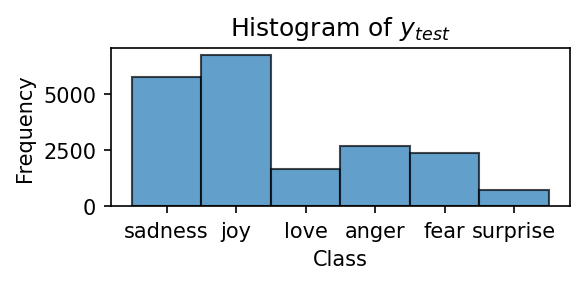

In [4]:
import matplotlib.pyplot as plt

# Create histograms for y_train and y_test
plt.figure(1, figsize=(4, 2), dpi=150)
plt.hist(y_test, bins=np.arange(y_test.min(), y_test.max() + 2) - 0.5,
         edgecolor='k', color='tab:blue', alpha=0.7)
plt.title("Histogram of $y_{test}$")
plt.xlabel('Class')
plt.ylabel('Frequency')

bin_labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
plt.xticks(ticks=np.arange(len(bin_labels)), labels=bin_labels)

plt.tight_layout()
plt.show()

## Load Synthetic Data

In [5]:
load_dir = root_dir / "results/emotion/gemini-2.0-flash/soft+cot/very_spiky"

print("Model directory:", load_dir)
print(*os.listdir(load_dir), sep="\n")

Model directory: /home/hgkahng/Workspaces/soft-prompt/results/emotion/gemini-2.0-flash/soft+cot/very_spiky
template.jsonl
main.log
embeddings
config.yaml
data.jsonl
template_formatted.txt


In [6]:
# Print configurations

with open(load_dir / 'config.yaml') as f:
    cfg = yaml.safe_load(f)

table = Table(title="Configuration(s)")
table.add_column("Name", justify="right", style="white", no_wrap=True)
table.add_column("Value", justify="left", style="red" if cfg['hard'] else "cyan")
_ = [table.add_row(k, str(v)) for k, v in cfg.items()]

console = Console()
console.print(table);

         Configuration(s)          
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃         Name ┃ Value            ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│      api_key │ None             │
│   batch_size │ 50               │
│          cot │ True             │
│         data │ emotion          │
│         hard │ False            │
│ log_interval │ 2                │
│   max_tokens │ None             │
│        model │ gemini-2.0-flash │
│  sample_size │ 200000           │
│     strategy │ very spiky       │
│  temperature │ 1.0              │
└──────────────┴──────────────────┘

In [7]:
with open(load_dir / 'template_formatted.txt') as f:
    template_example = "".join(f.readlines())

print(template_example)

system:
You are an AI language model assistant trained to generate emotionally nuanced text.
You will receive an emotion distribution across six emotions (sadness, joy, love, anger, fear, surprise),
where each value indicates the strength of that emotion and all values sum to 1.
Your task is to generate text that reflects this emotional distribution.
Before writing your final answer, please think step-by-step.
Ensure that you MUST provide your step-by-step thinking process in the final output.
human:
Generate text that reflects the following emotional distribution: {'sadness': 0.0, 'joy': 0.029, 'love': 0.742, 'anger': 0.002, 'fear': 0.227, 'surprise': 0.0}



In [8]:
with open(load_dir / "data.jsonl", "r") as f:
    data = [json.loads(line) for line in f]

print(len(data))

200049


In [9]:
data[0]  # demo

{'label': [0.028, 0.0, 0.965, 0.0, 0.0, 0.006],
 'text': "My heart overflows with love for you. A bittersweet ache reminds me of the times we've been apart, but it only deepens the ocean of my affection. Seeing you again... it's like a dream, a beautiful, unexpected gift. I cherish every moment. ",
 'reasoning': 'The emotion distribution indicates a very strong presence of love, a trace of sadness, and a hint of surprise. The text should be overwhelmingly positive and filled with affection, while also containing a very slight sense of melancholy and wonder.'}

Check length distribution

In [10]:
# TODO: 

Filter invalid examples (this happens seldomly)

In [11]:
labels = [d['label'] for d in data]

# Check for invalid labels
mask = np.array([len(l) == 6 for l in labels])
valid_idx = np.where(mask)[0]
invalid_idx = np.where(~mask)[0]  # discarded

labels = [l for i, l in enumerate(labels) if i in valid_idx]
labels = np.array(labels)             # soft vectors 
hard_labels = labels.argmax(axis=-1)  # label indicators
soft_labels = labels / labels.sum(axis=1, keepdims=True)  # normalized
assert soft_labels.sum(axis=1).all()  # check row sum = 1 (valid probabilities)

print("Hard labels, shape:", hard_labels.shape)
print("Soft labels, shape:", soft_labels.shape)

Hard labels, shape: (200047,)
Soft labels, shape: (200047, 6)


Check distribution of labels
- hard
- soft (the maximum probability of each example)

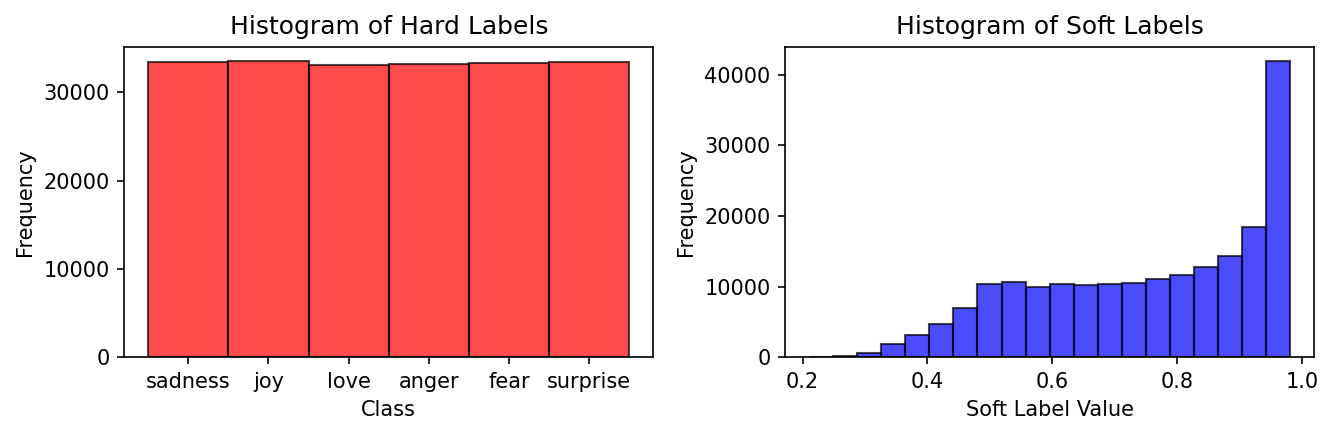

In [12]:
plt.figure(figsize=(9, 3), dpi=150)

# Histogram for hard_labels
plt.subplot(1, 2, 1)
plt.hist(hard_labels, bins=np.arange(hard_labels.min(), hard_labels.max() + 2) - 0.5,
         edgecolor='k', color='red', alpha=0.7)
plt.title('Histogram of Hard Labels')
plt.xlabel('Class')
plt.ylabel('Frequency')
bin_labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
plt.xticks(ticks=np.arange(len(bin_labels)), labels=bin_labels)

# Histogram for soft_labels (max)
plt.subplot(1, 2, 2)
plt.hist(soft_labels.max(axis=1), bins=20, edgecolor='k', align='left', color='blue', alpha=0.7)
plt.title('Histogram of Soft Labels')
plt.xlabel('Soft Label Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [13]:
invalid_idx  # remove these from embeddings as well

array([181826, 196606])

In [14]:
valid_idx

array([     0,      1,      2, ..., 200046, 200047, 200048],
      shape=(200047,))

In [15]:
embeddings = np.load(
    load_dir / "embeddings/openai/text-embedding-3-small/data.npy"
)
embeddings = embeddings[valid_idx]
print(embeddings.shape)

(200047, 1536)


In [16]:
assert len(hard_labels) == embeddings.shape[0]
assert len(soft_labels) == embeddings.shape[0]

In [17]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

## Evaluation

### 1. Classification Performance

In [18]:
from softprompt.algorithms.helpers import (
    evaluate_logreg_cv_experiment
)

In [19]:
X_syn = embeddings.copy()
y_syn_soft = soft_labels.copy()
y_syn_hard = hard_labels.copy()
print(X_syn.shape, y_syn_soft.shape, y_syn_hard.shape)

(200047, 1536) (200047, 6) (200047,)


With different sizes of synthetic data
- $\text{ratio} \in \{0.01, 0.05, 0.10, 0.25, 0.50, 1.00\}$  

In [20]:
print(f"Dirichlet sampling strategy: {cfg['strategy']}")

N = 89_832  # train size
ratios = (0.01, 0.05, 0.10, 0.25, 0.50, 1.00)
subsample_sizes = [int(N * r) for r in ratios]

for i, subsample_size in enumerate(subsample_sizes):
    console = Console()
    console.print(
        f"Subsample Ratio: {ratios[i]:.2f} (Size: {subsample_size:,})"
    )
    try:
        tr_metrics, te_metrics = evaluate_logreg_cv_experiment(
            X_train_full=X_syn,
            y_train_full_probs=y_syn_soft,
            X_test=X_test,
            y_test_hard=y_test,
            subsample_size=subsample_size,
            model_variant='standard',
            solver='lbfgs',
            max_iter_solver=1000,
            bootstrap=True,
            n_trials=30,
        )
    except ValueError as e:
        print(f"Skipping subsample size {i} (Error: {e})")

    from rich.table import Table
    table = Table(title=f"Metrics (r={ratios[i]:.2f})")
    table.add_column("Metric Name", style='cyan', no_wrap=True, justify='left')
    table.add_column("Train", style='white', justify='center')
    table.add_column("Test", style='white', justify='center')
    for name in tr_metrics.keys():
        tr_mean_, tr_std_ = tr_metrics[name]
        tr_metric_value_str = f"{tr_mean_:.4f} (± {tr_std_:.4f})"
        te_mean_, te_std_ = te_metrics[name]
        te_metric_value_str = f"{te_mean_:.4f} (± {te_std_:.4f})"
        table.add_row(
            name,
            tr_metric_value_str,
            te_metric_value_str,
        )
    console.print(table);

Dirichlet sampling strategy: very spiky


Subsample Ratio: 0.01 (Size: 898)

                   Metrics (r=0.01)                    
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.9186 (± 0.0022) │ 0.4969 (± 0.0230) │
│ precision   │ 0.9188 (± 0.0022) │ 0.4449 (± 0.0205) │
│ recall      │ 0.9187 (± 0.0022) │ 0.3891 (± 0.0230) │
│ f1_score    │ 0.9185 (± 0.0022) │ 0.3822 (± 0.0213) │
│ roc_auc     │ 0.9945 (± 0.0003) │ 0.7755 (± 0.0086) │
│ auprc       │ 0.9758 (± 0.0013) │ 0.4206 (± 0.0131) │
│ ece         │ 0.0057 (± 0.0019) │ 0.0682 (± 0.0141) │
└─────────────┴───────────────────┴───────────────────┘

Subsample Ratio: 0.05 (Size: 4,491)

                   Metrics (r=0.05)                    
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.9319 (± 0.0011) │ 0.4754 (± 0.0306) │
│ precision   │ 0.9319 (± 0.0011) │ 0.4265 (± 0.0171) │
│ recall      │ 0.9319 (± 0.0011) │ 0.3774 (± 0.0176) │
│ f1_score    │ 0.9318 (± 0.0011) │ 0.3585 (± 0.0204) │
│ roc_auc     │ 0.9961 (± 0.0001) │ 0.7571 (± 0.0087) │
│ auprc       │ 0.9827 (± 0.0005) │ 0.3910 (± 0.0133) │
│ ece         │ 0.0037 (± 0.0005) │ 0.0931 (± 0.0127) │
└─────────────┴───────────────────┴───────────────────┘

...

                   Metrics (r=0.25)                    
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.9397 (± 0.0004) │ 0.5073 (± 0.0132) │
│ precision   │ 0.9396 (± 0.0004) │ 0.4525 (± 0.0105) │
│ recall      │ 0.9397 (± 0.0004) │ 0.4006 (± 0.0101) │
│ f1_score    │ 0.9397 (± 0.0004) │ 0.3906 (± 0.0094) │
│ roc_auc     │ 0.9971 (± 0.0000) │ 0.7802 (± 0.0038) │
│ auprc       │ 0.9866 (± 0.0002) │ 0.4255 (± 0.0067) │
│ ece         │ 0.0040 (± 0.0003) │ 0.0646 (± 0.0073) │
└─────────────┴───────────────────┴───────────────────┘

Subsample Ratio: 0.50 (Size: 44,916)

                   Metrics (r=0.50)                    
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.9431 (± 0.0003) │ 0.4895 (± 0.0090) │
│ precision   │ 0.9431 (± 0.0003) │ 0.4434 (± 0.0072) │
│ recall      │ 0.9431 (± 0.0003) │ 0.3930 (± 0.0075) │
│ f1_score    │ 0.9431 (± 0.0003) │ 0.3797 (± 0.0075) │
│ roc_auc     │ 0.9974 (± 0.0000) │ 0.7726 (± 0.0025) │
│ auprc       │ 0.9881 (± 0.0001) │ 0.4125 (± 0.0044) │
│ ece         │ 0.0029 (± 0.0002) │ 0.0756 (± 0.0048) │
└─────────────┴───────────────────┴───────────────────┘

Subsample Ratio: 1.00 (Size: 89,832)

                   Metrics (r=1.00)                    
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.9384 (± 0.0002) │ 0.5240 (± 0.0034) │
│ precision   │ 0.9383 (± 0.0002) │ 0.4681 (± 0.0048) │
│ recall      │ 0.9384 (± 0.0002) │ 0.4092 (± 0.0050) │
│ f1_score    │ 0.9383 (± 0.0002) │ 0.4027 (± 0.0046) │
│ roc_auc     │ 0.9970 (± 0.0000) │ 0.7923 (± 0.0014) │
│ auprc       │ 0.9861 (± 0.0001) │ 0.4452 (± 0.0026) │
│ ece         │ 0.0069 (± 0.0001) │ 0.0528 (± 0.0028) │
└─────────────┴───────────────────┴───────────────────┘

### 2. Confidence-based Filtering
- For multiclass tasks, we cannot define a margin $m$ around 0.5.
- There are alternatives: 1) `filter_by_max_prob`, 2) `filter_by_top_gap`, 3) `filter_by_entropy`

With entropy-based filtering
- Filter data starting from the most ambiguous samples.
- Ambiugous samples have high entropy. 

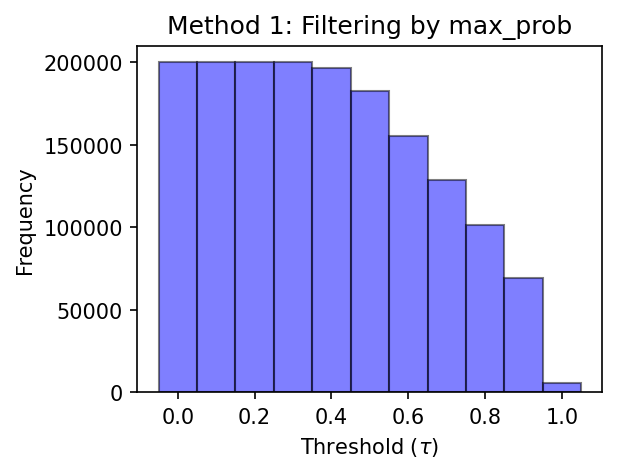

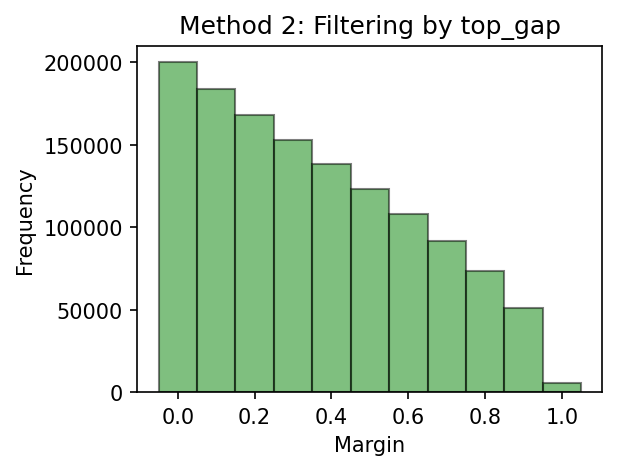

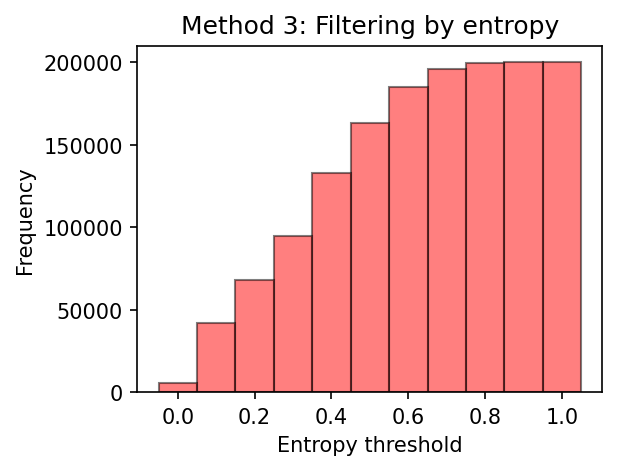

In [21]:
def filter_by_max_prob(y: np.ndarray, threshold: float = 0.7) -> np.ndarray:
    # is the maximum probability larger than the threshold? 
    assert y.ndim == 2
    return np.max(y, axis=-1) >= threshold  


def filter_by_top_gap(y: np.ndarray, margin: float = 0.2) -> np.ndarray:
    # Is the difference between the highest and second highest probability larger than the margin?
    assert y.ndim == 2
    sorted_probs = np.sort(y, axis=-1)
    return (sorted_probs[:, -1] - sorted_probs[:, -2]) >= margin


def filter_by_entropy(y: np.ndarray, max_entropy: float = 1.0, eps: float = 1e-10) -> np.ndarray:
    # Looking at the whole distribution... is the entropy smaller than `max_entropy`?
    # Small entropy indicates a sharp & spiky distribution
    assert y.ndim == 2
    H = - np.sum(y * np.log(y + eps) / np.log(y.shape[1]), axis=-1)
    return H <= max_entropy  # spiky probs = small entropy (flat probs = large entropy)


# Method 1: discarding from training set if the largest probability
#           is smaller than some threshold

thresholds = [.0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1.0]
counts = []
for t in thresholds:
    counts.append(
        filter_by_max_prob(soft_labels, threshold=t).sum()
    )

plt.figure(1, figsize=(4,3), dpi=150)
plt.bar(thresholds, counts, width=.1, edgecolor='k', alpha=.5, color='b')
plt.title(f"Method 1: Filtering by max_prob")
plt.xlabel(r"Threshold $(\tau)$")
plt.ylabel("Frequency")
plt.show()

# Method 2: discarding from training set if the difference between the first and
#           second largest probabilities is larger than a margin value

margins = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
counts = []
for m in margins:
    counts.append(
        filter_by_top_gap(soft_labels, margin=m).sum()
    )

plt.figure(1, figsize=(4,3), dpi=150)
plt.bar(margins, counts, width=.1, edgecolor='k', alpha=.5, color='g')
plt.title(f"Method 2: Filtering by top_gap")
plt.xlabel("Margin")
plt.ylabel("Frequency")
plt.show()

# Method 3
max_entropies = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.0]
counts = []
for e in max_entropies:
    counts.append(
        filter_by_entropy(soft_labels, max_entropy=e).sum()
    )

plt.figure(1, figsize=(4,3), dpi=150)
plt.bar(max_entropies, counts, width=.1, edgecolor='k', alpha=.5, color='r')
plt.title(f"Method 3: Filtering by entropy")
plt.xlabel("Entropy threshold")
plt.ylabel("Frequency")
plt.show()

In [22]:
print(X_syn.shape[0])

200047


Margin

In [23]:
margin_to_metrics = {}
margins = (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9)
for m in margins:
    # compute entropy mask
    margin_mask = filter_by_top_gap(y_syn_soft, margin=m)
    effective_indices = np.where(margin_mask)[0]
    if len(effective_indices) == 0:
        console.print(f">> Effective pool size is 0 with top_gap margin = {m:.2f}. Skipping.")
        margin_to_metrics[m] = {'train': [], 'test': []}  # store empty
        continue

    X_syn_filtered = X_syn[effective_indices]
    y_syn_soft_filtered = y_syn_soft[effective_indices] # This is 1D
    N_filtered = len(X_syn_filtered)
    console.print(f">> Effective pool size is {N_filtered:,} with  top_gap margin = {m:.2f}")

    # Store metrics for this margin across different subsample ratios
    from typing import Dict, List
    train_metrics_for_all_ratios: Dict[str, List[List[float]]] = {}
    test_metrics_for_all_ratios: Dict[str, List[List[float]]] = {}

    N = 89_832
    ratios = (0.01, 0.05, 0.10, 0.25, 0.50, 1.00)
    subsample_sizes = [int(N * r) for r in ratios]

    for i, subsample_size in enumerate(subsample_sizes):
        console = Console()
        console.print(
            f"Subsample Ratio: {ratios[i]:.2f} (Size: {subsample_size:,})"
        )
        try:
            tr_metrics, te_metrics = evaluate_logreg_cv_experiment(
                X_train_full=X_syn,
                y_train_full_probs=y_syn_soft,
                X_test=X_test,
                y_test_hard=y_test,
                subsample_size=subsample_size,
                model_variant='standard',
                solver='lbfgs',
                max_iter_solver=1000,
                bootstrap=True,
                n_trials=30,
                n_jobs_cv=16,
            )
        except ValueError as e:
            print(f"Skipping subsample size {i} (Error: {e})")

        from rich.table import Table
        table = Table(title=f"Metrics (top_gap_margin={m:.2f}, ratio={ratios[i]:.2f})")
        table.add_column("Metric Name", style='cyan', no_wrap=True, justify='left')
        table.add_column("Train", style='white', justify='center')
        table.add_column("Test", style='white', justify='center')
        for name in tr_metrics.keys():
            tr_mean_, tr_std_ = tr_metrics[name]
            tr_metric_value_str = f"{tr_mean_:.4f} (± {tr_std_:.4f})"
            te_mean_, te_std_ = te_metrics[name]
            te_metric_value_str = f"{te_mean_:.4f} (± {te_std_:.4f})"
            table.add_row(
                name,
                tr_metric_value_str,
                te_metric_value_str,
            )
        console.print(table);

        # Store all metrics for this ratio
        for metric_name, (mean_val, std_val) in tr_metrics.items():
            if metric_name not in train_metrics_for_all_ratios:
                train_metrics_for_all_ratios[metric_name] = []
            train_metrics_for_all_ratios[metric_name].append([mean_val, std_val])
        
        for metric_name, (mean_val, std_val) in te_metrics.items():
            if metric_name not in test_metrics_for_all_ratios:
                test_metrics_for_all_ratios[metric_name] = []
            test_metrics_for_all_ratios[metric_name].append([mean_val, std_val])

    margin_to_metrics[e] = {
        'train': train_metrics_for_all_ratios,
        'test': test_metrics_for_all_ratios,
    }

>> Effective pool size is 183,716 with  top_gap margin = 0.10

Subsample Ratio: 0.01 (Size: 898)

       Metrics (top_gap_margin=0.10, ratio=0.01)       
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.9186 (± 0.0022) │ 0.4969 (± 0.0230) │
│ precision   │ 0.9188 (± 0.0022) │ 0.4449 (± 0.0205) │
│ recall      │ 0.9187 (± 0.0022) │ 0.3891 (± 0.0230) │
│ f1_score    │ 0.9185 (± 0.0022) │ 0.3822 (± 0.0213) │
│ roc_auc     │ 0.9945 (± 0.0003) │ 0.7755 (± 0.0086) │
│ auprc       │ 0.9758 (± 0.0013) │ 0.4206 (± 0.0131) │
│ ece         │ 0.0057 (± 0.0019) │ 0.0682 (± 0.0141) │
└─────────────┴───────────────────┴───────────────────┘

Subsample Ratio: 0.05 (Size: 4,491)

       Metrics (top_gap_margin=0.10, ratio=0.05)       
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.9319 (± 0.0010) │ 0.4751 (± 0.0309) │
│ precision   │ 0.9319 (± 0.0011) │ 0.4262 (± 0.0168) │
│ recall      │ 0.9319 (± 0.0010) │ 0.3774 (± 0.0174) │
│ f1_score    │ 0.9318 (± 0.0010) │ 0.3583 (± 0.0204) │
│ roc_auc     │ 0.9961 (± 0.0001) │ 0.7570 (± 0.0087) │
│ auprc       │ 0.9827 (± 0.0005) │ 0.3909 (± 0.0134) │
│ ece         │ 0.0036 (± 0.0005) │ 0.0931 (± 0.0128) │
└─────────────┴───────────────────┴───────────────────┘

...

       Metrics (top_gap_margin=0.90, ratio=0.25)       
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.9397 (± 0.0004) │ 0.5075 (± 0.0128) │
│ precision   │ 0.9396 (± 0.0004) │ 0.4527 (± 0.0105) │
│ recall      │ 0.9397 (± 0.0004) │ 0.4007 (± 0.0101) │
│ f1_score    │ 0.9396 (± 0.0004) │ 0.3908 (± 0.0091) │
│ roc_auc     │ 0.9971 (± 0.0000) │ 0.7803 (± 0.0037) │
│ auprc       │ 0.9866 (± 0.0001) │ 0.4257 (± 0.0064) │
│ ece         │ 0.0040 (± 0.0003) │ 0.0644 (± 0.0068) │
└─────────────┴───────────────────┴───────────────────┘

Subsample Ratio: 0.50 (Size: 44,916)

       Metrics (top_gap_margin=0.90, ratio=0.50)       
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.9431 (± 0.0003) │ 0.4890 (± 0.0088) │
│ precision   │ 0.9431 (± 0.0003) │ 0.4427 (± 0.0075) │
│ recall      │ 0.9432 (± 0.0003) │ 0.3928 (± 0.0074) │
│ f1_score    │ 0.9431 (± 0.0003) │ 0.3793 (± 0.0074) │
│ roc_auc     │ 0.9974 (± 0.0000) │ 0.7725 (± 0.0025) │
│ auprc       │ 0.9881 (± 0.0001) │ 0.4123 (± 0.0043) │
│ ece         │ 0.0029 (± 0.0002) │ 0.0758 (± 0.0047) │
└─────────────┴───────────────────┴───────────────────┘

Subsample Ratio: 1.00 (Size: 89,832)

       Metrics (top_gap_margin=0.90, ratio=1.00)       
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.9384 (± 0.0002) │ 0.5240 (± 0.0034) │
│ precision   │ 0.9383 (± 0.0002) │ 0.4681 (± 0.0048) │
│ recall      │ 0.9384 (± 0.0002) │ 0.4092 (± 0.0050) │
│ f1_score    │ 0.9383 (± 0.0002) │ 0.4027 (± 0.0046) │
│ roc_auc     │ 0.9970 (± 0.0000) │ 0.7923 (± 0.0014) │
│ auprc       │ 0.9861 (± 0.0001) │ 0.4452 (± 0.0026) │
│ ece         │ 0.0069 (± 0.0001) │ 0.0528 (± 0.0028) │
└─────────────┴───────────────────┴───────────────────┘

In [30]:
entropy_to_metrics = {}
max_entropies = (0.9, 0.8, 0.7, 0.6, 0.5)
for e in max_entropies:
    # compute entropy mask
    entropy_mask = filter_by_entropy(y_syn_soft, max_entropy=e)
    effective_indices = np.where(entropy_mask)[0]
    if len(effective_indices) == 0:
        console.print(f">> Effective pool size is 0 with max_entropy = {e:.2f}. Skipping.")
        entropy_to_metrics[e] = {'train': [], 'test': []}  # store empty
        continue

    X_syn_filtered = X_syn[effective_indices]
    y_syn_soft_filtered = y_syn_soft[effective_indices] # This is 1D
    N_filtered = len(X_syn_filtered)
    console.print(f">> Effective pool size is {N_filtered:,} with max_entropy = {e:.2f}")

    # Store metrics for this margin across different subsample ratios
    from typing import Dict, List
    train_metrics_for_all_ratios: Dict[str, List[List[float]]] = {}
    test_metrics_for_all_ratios: Dict[str, List[List[float]]] = {}

    N = 89_832
    ratios = (0.01, 0.05, 0.10, 0.25, 0.50, 1.00)
    subsample_sizes = [int(N * r) for r in ratios]

    for i, subsample_size in enumerate(subsample_sizes):
        console = Console()
        console.print(
            f"Subsample Ratio: {ratios[i]:.2f} (Size: {subsample_size:,})"
        )
        try:
            tr_metrics, te_metrics = evaluate_logreg_cv_experiment(
                X_train_full=X_syn,
                y_train_full_probs=y_syn_soft,
                X_test=X_test,
                y_test_hard=y_test,
                subsample_size=subsample_size,
                model_variant='standard',
                solver='lbfgs',
                max_iter_solver=1000,
                bootstrap=True,
                n_trials=30,
            )
        except ValueError as e:
            print(f"Skipping subsample size {i} (Error: {e})")

        from rich.table import Table
        table = Table(title=f"Metrics (e={e:.2f}, r={ratios[i]:.2f})")
        table.add_column("Metric Name", style='cyan', no_wrap=True, justify='left')
        table.add_column("Train", style='white', justify='center')
        table.add_column("Test", style='white', justify='center')
        for name in tr_metrics.keys():
            tr_mean_, tr_std_ = tr_metrics[name]
            tr_metric_value_str = f"{tr_mean_:.4f} (± {tr_std_:.4f})"
            te_mean_, te_std_ = te_metrics[name]
            te_metric_value_str = f"{te_mean_:.4f} (± {te_std_:.4f})"
            table.add_row(
                name,
                tr_metric_value_str,
                te_metric_value_str,
            )
        console.print(table);

        # Store all metrics for this ratio
        for metric_name, (mean_val, std_val) in tr_metrics.items():
            if metric_name not in train_metrics_for_all_ratios:
                train_metrics_for_all_ratios[metric_name] = []
            train_metrics_for_all_ratios[metric_name].append([mean_val, std_val])
        
        for metric_name, (mean_val, std_val) in te_metrics.items():
            if metric_name not in test_metrics_for_all_ratios:
                test_metrics_for_all_ratios[metric_name] = []
            test_metrics_for_all_ratios[metric_name].append([mean_val, std_val])

    entropy_to_metrics[e] = {
        'train': train_metrics_for_all_ratios,
        'test': test_metrics_for_all_ratios,
    }

>> Effective pool size is 100,998 with max_entropy = 0.90

Subsample Ratio: 0.01 (Size: 898)

               Metrics (e=0.90, r=0.01)                
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.9996 (± 0.0002) │ 0.3938 (± 0.0100) │
│ precision   │ 0.9996 (± 0.0002) │ 0.4711 (± 0.0099) │
│ recall      │ 0.9996 (± 0.0002) │ 0.3978 (± 0.0069) │
│ f1_score    │ 0.9996 (± 0.0002) │ 0.3354 (± 0.0072) │
│ roc_auc     │ 1.0000 (± 0.0000) │ 0.7842 (± 0.0022) │
│ auprc       │ 1.0000 (± 0.0000) │ 0.4391 (± 0.0032) │
│ ece         │ 0.0036 (± 0.0002) │ 0.1029 (± 0.0045) │
└─────────────┴───────────────────┴───────────────────┘

Subsample Ratio: 0.05 (Size: 4,491)

               Metrics (e=0.90, r=0.05)                
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Metric Name ┃       Train       ┃       Test        ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ accuracy    │ 0.9998 (± 0.0001) │ 0.3991 (± 0.0083) │
│ precision   │ 0.9998 (± 0.0001) │ 0.4814 (± 0.0122) │
│ recall      │ 0.9998 (± 0.0001) │ 0.4002 (± 0.0032) │
│ f1_score    │ 0.9998 (± 0.0001) │ 0.3395 (± 0.0049) │
│ roc_auc     │ 1.0000 (± 0.0000) │ 0.7833 (± 0.0012) │
│ auprc       │ 1.0000 (± 0.0000) │ 0.4411 (± 0.0019) │
│ ece         │ 0.0010 (± 0.0004) │ 0.1111 (± 0.0039) │
└─────────────┴───────────────────┴───────────────────┘

Subsample Ratio: 0.10 (Size: 8,983)

KeyboardInterrupt: 